Visualizing top 200 elites (out of 200)
  Reconstructing elite 1/200 (ID=989.4214883989983, fitness=443.75)... OK
  Reconstructing elite 2/200 (ID=907.4663618819557, fitness=188.00)... OK
  Reconstructing elite 3/200 (ID=915.4240230620594, fitness=149.00)... OK
  Reconstructing elite 4/200 (ID=733.8345204391965, fitness=48.75)... OK
  Reconstructing elite 5/200 (ID=562.5750417564195, fitness=46.00)... OK
  Reconstructing elite 6/200 (ID=620.6156714674534, fitness=45.25)... OK
  Reconstructing elite 7/200 (ID=834.4056896025501, fitness=45.25)... OK
  Reconstructing elite 8/200 (ID=303.3463284235443, fitness=43.00)... OK
  Reconstructing elite 9/200 (ID=329.6048153100621, fitness=43.00)... OK
  Reconstructing elite 10/200 (ID=643.4649237664341, fitness=42.75)... OK
  Reconstructing elite 11/200 (ID=439.5304980742662, fitness=42.75)... OK
  Reconstructing elite 12/200 (ID=726.4940574874413, fitness=41.50)... OK
  Reconstructing elite 13/200 (ID=561.403125732224, fitness=40.75)... OK
  Rec

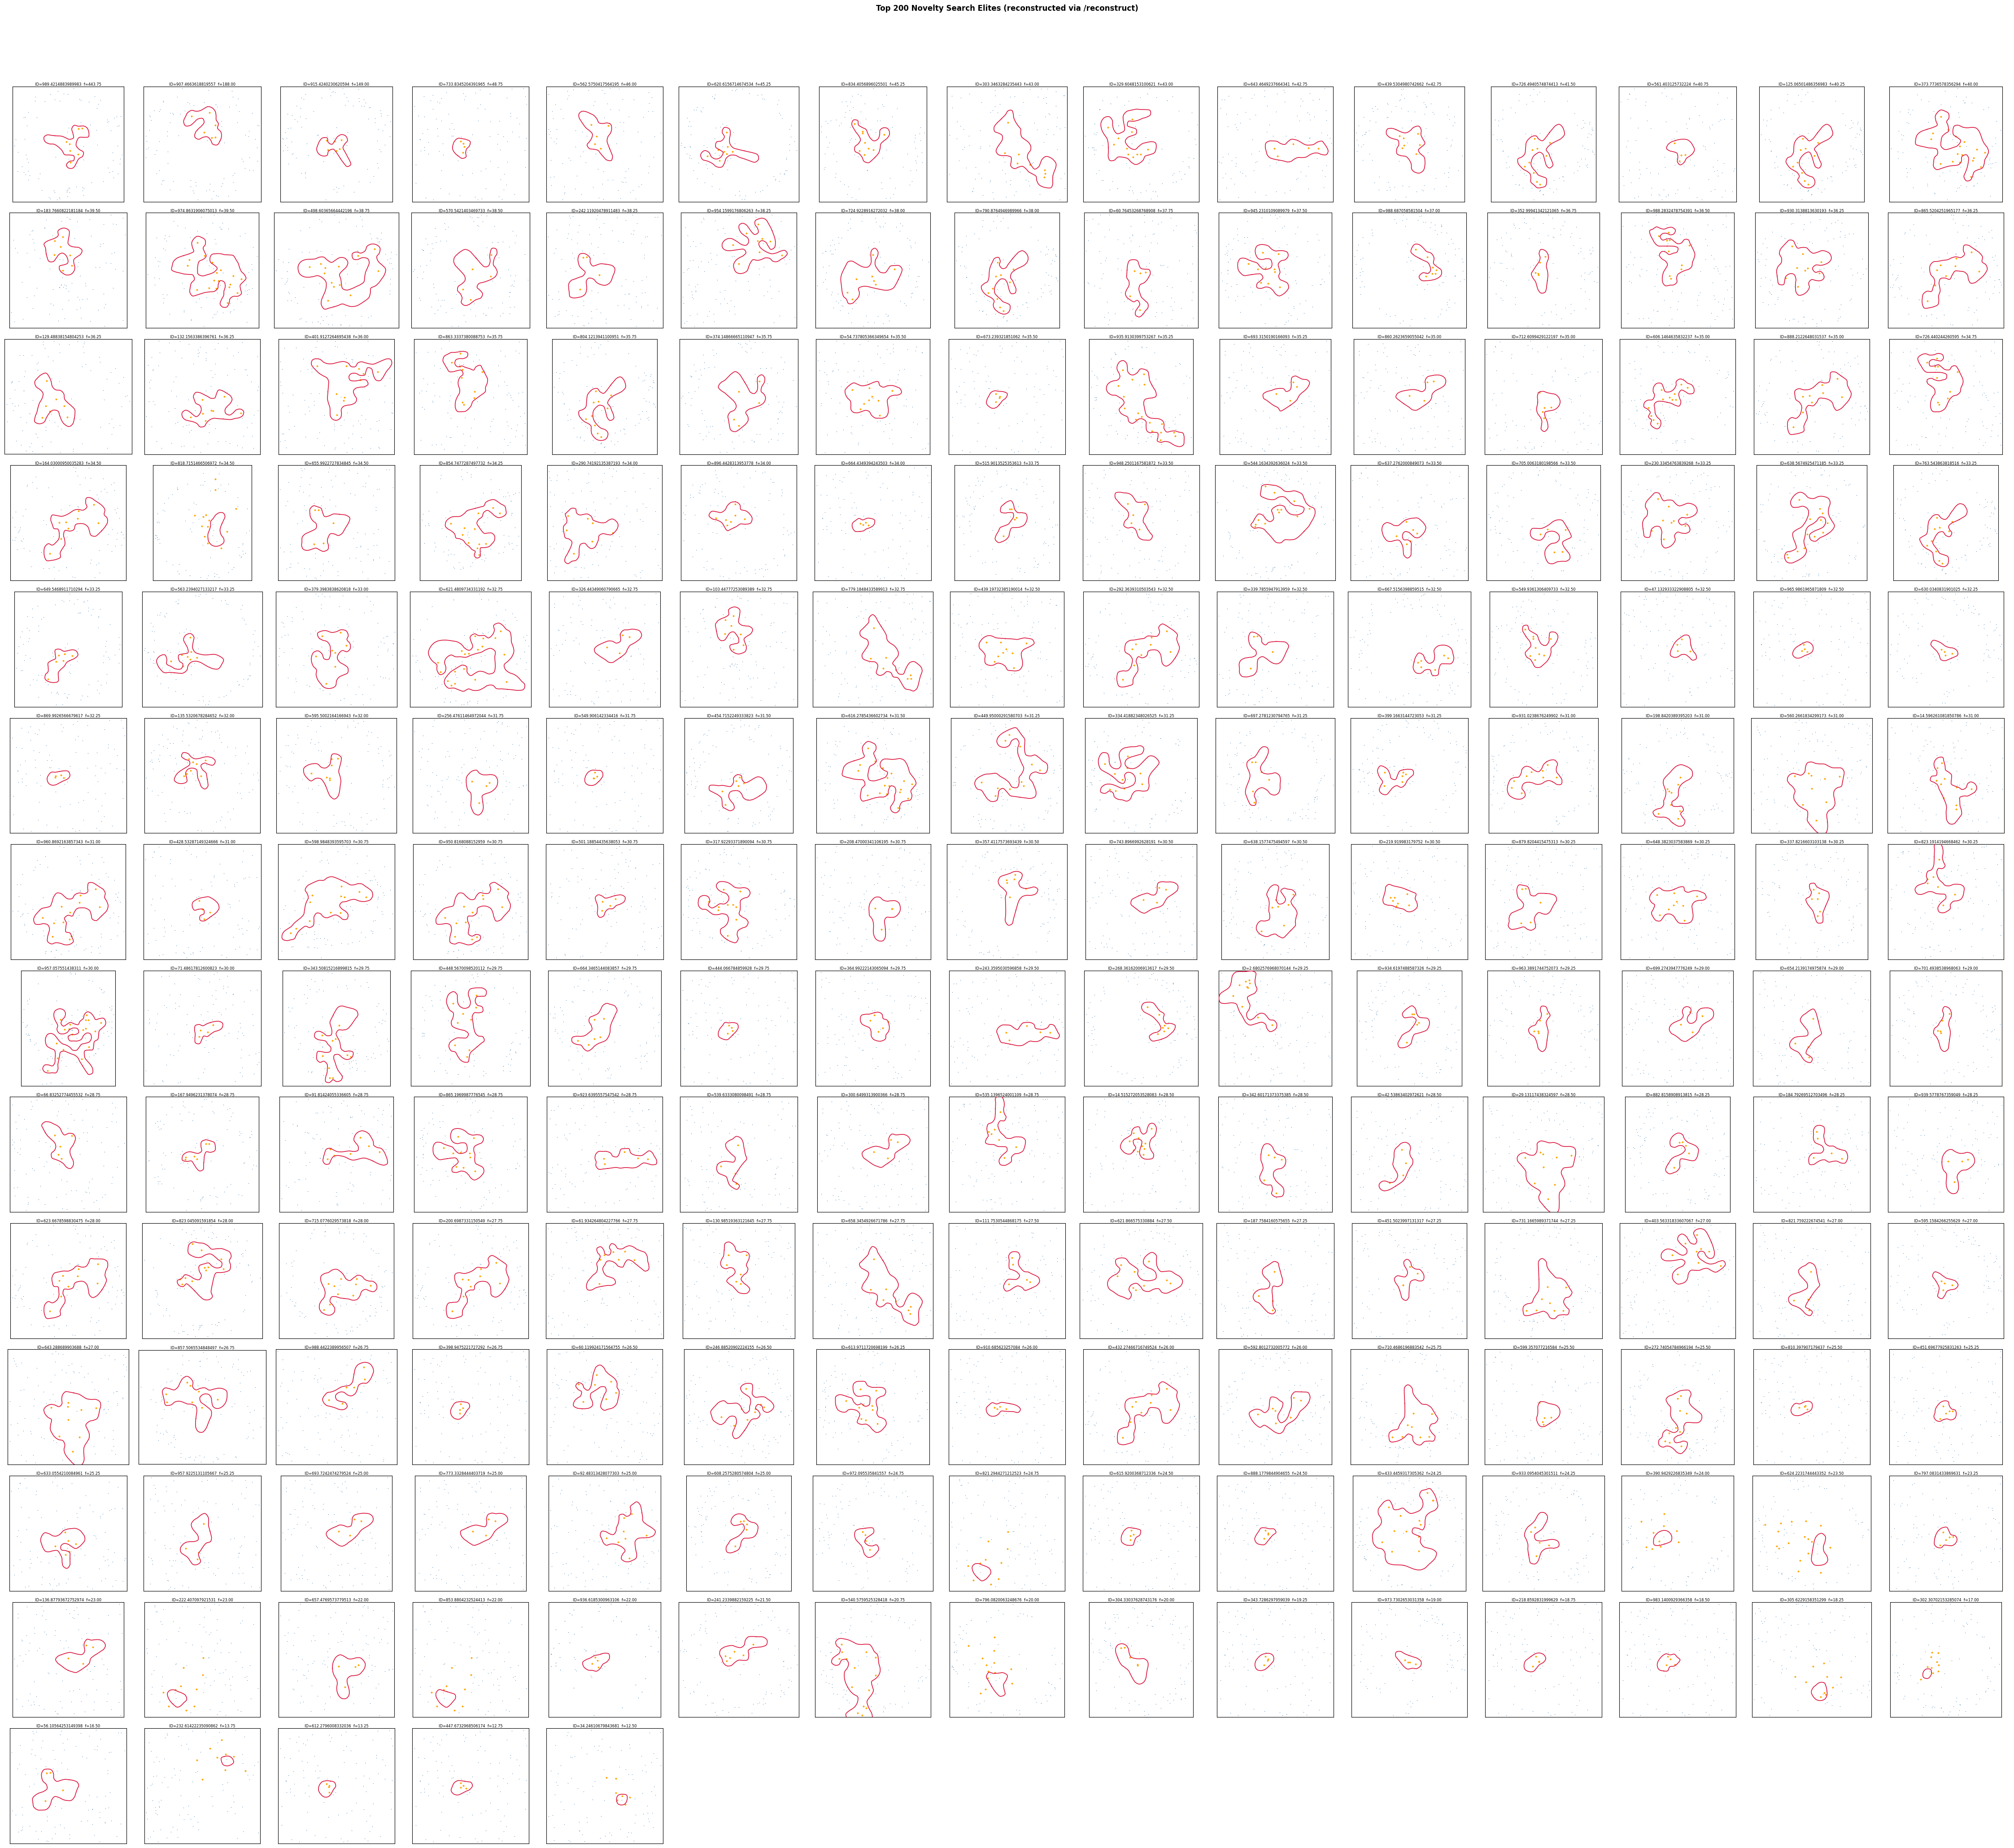

In [1]:
# --- Reconstruct & visualize elite tracks via /reconstruct endpoint ---
import requests
import matplotlib.pyplot as plt
import math
import json
import numpy as np

API_URL = "http://localhost:4242/reconstruct"
ELITES_FILE = "data/elites.json"
MAX_TRACKS = 200  # number of top elites to visualize

# Load saved elites
with open(ELITES_FILE, "r") as f:
    elites_data = json.load(f)

elites = elites_data["elites"][:MAX_TRACKS]  # already sorted by fitness desc
print(f"Visualizing top {len(elites)} elites (out of {elites_data['metadata']['totalElites']})")

cols = int(math.ceil(math.sqrt(len(elites))))
rows = int(math.ceil(len(elites) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = np.array(axes).flatten()

for idx, elite in enumerate(elites):
    ax = axes[idx]
    print(f"  Reconstructing elite {idx+1}/{len(elites)} "
          f"(ID={elite['id']}, fitness={elite['fitness']:.2f})...", end=" ", flush=True)

    try:
        resp = requests.post(API_URL, json={
            "mode":          elite["mode"],
            "seed":          elite["id"],
            "dataSet":       elite["dataSet"],
            "selectedCells": elite["selectedCells"],
            "trackSize":     elite["trackSize"],
        }, timeout=10)
        resp.raise_for_status()
        data = resp.json()
    except Exception as e:
        print(f"FAILED: {e}")
        ax.set_title(f"#{elite['id']} ERR", fontsize=6, color="red")
        ax.axis("off")
        continue

    track = data["track"]

    # --- Dataset points (blue dots) ---
    ds = data["dataSet"]
    ds_x = [p["x"] for p in ds]
    ds_y = [p["y"] for p in ds]
    ax.scatter(ds_x, ds_y, s=1, c="steelblue", zorder=2, linewidths=0)

    # --- Selected cells (orange dots) ---
    sel = data["selectedCells"]
    if sel:
        sel_x = [p["x"] for p in sel]
        sel_y = [p["y"] for p in sel]
        ax.scatter(sel_x, sel_y, s=8, c="orange", zorder=3, linewidths=0)

    # --- Track spline (closed loop) ---
    tx = [p["x"] for p in track]
    ty = [p["y"] for p in track]
    tx.append(tx[0])
    ty.append(ty[0])
    ax.plot(tx, ty, color="crimson", linewidth=1.2, zorder=4)

    # --- Formatting ---
    ax.set_xlim(min(ds_x) - 10, max(ds_x) + 10)
    ax.set_ylim(min(ds_y) - 10, max(ds_y) + 10)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.set_title(f"ID={elite['id']}  f={elite['fitness']:.2f}", fontsize=6, pad=2)
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    print("OK")

# Hide unused subplots
for idx in range(len(elites), len(axes)):
    axes[idx].axis("off")

fig.suptitle(f"Top {len(elites)} Novelty Search Elites (reconstructed via /reconstruct)",
             fontsize=12, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


In [2]:
# test cell to debug api
# send a request for only one specific elite — change ELITE_ID to pick a different one

ELITE_ID = 852.2659244869802  # <-- change this to the ID of the elite you want to visualize

elite = next((e for e in elites_data["elites"] if e["id"] == ELITE_ID), None)
if elite is None:
    valid_ids = [e["id"] for e in elites_data["elites"][:20]]
    raise ValueError(f"Elite ID={ELITE_ID} not found. First 20 IDs: {valid_ids}")

print(f"Elite ID={elite['id']}, fitness={elite['fitness']:.2f}, "
      f"mode={elite['mode']}, trackSize={elite['trackSize']}")

resp = requests.post(API_URL, json={
    "mode":          elite["mode"],
    "dataSet":       elite["dataSet"],
    "selectedCells": elite["selectedCells"],
    "trackSize":     elite["trackSize"],
}, timeout=10)
resp.raise_for_status()
data = resp.json()

# --- Plot single track ---
fig, ax = plt.subplots(figsize=(6, 6))

# Dataset points
ds = data["dataSet"]
ds_x = [p["x"] for p in ds]
ds_y = [p["y"] for p in ds]
ax.scatter(ds_x, ds_y, s=4, c="steelblue", zorder=2, linewidths=0, label="Dataset")

# Selected cells
sel = data["selectedCells"]
if sel:
    sel_x = [p["x"] for p in sel]
    sel_y = [p["y"] for p in sel]
    ax.scatter(sel_x, sel_y, s=30, c="orange", zorder=3, linewidths=0, label="Selected cells")

# Track spline (closed loop)
track = data["track"]
tx = [p["x"] for p in track] + [track[0]["x"]]
ty = [p["y"] for p in track] + [track[0]["y"]]
ax.plot(tx, ty, color="crimson", linewidth=1.5, zorder=4, label="Track")

ax.set_xlim(min(ds_x) - 10, max(ds_x) + 10)
ax.set_ylim(min(ds_y) - 10, max(ds_y) + 10)
ax.invert_yaxis()
ax.set_aspect("equal")
ax.legend(fontsize=8)
ax.set_title(f"Elite ID={elite['id']}  fitness={elite['fitness']:.2f}", fontsize=10)
plt.tight_layout()
plt.show()


ValueError: Elite ID=852.2659244869802 not found. First 20 IDs: [989.4214883989983, 907.4663618819557, 915.4240230620594, 733.8345204391965, 562.5750417564195, 620.6156714674534, 834.4056896025501, 303.3463284235443, 329.6048153100621, 643.4649237664341, 439.5304980742662, 726.4940574874413, 561.403125732224, 125.06501486356983, 373.7736578356294, 183.7660822181184, 974.8631906075013, 498.60365664442196, 570.5421403469733, 242.11920478911483]